In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("Librerías importadas correctamente ✅")

Librerías importadas correctamente ✅


## Recordatorio del EDA

En el Challenge 1 exploramos el dataset de California Housing y encontramos:

- El dataset tiene 20,640 registros y 10 columnas
- `total_bedrooms` tiene 207 valores nulos (~1%) — imputados con la mediana agrupada por `ocean_proximity`
- `median_house_value` tiene un tope artificial en $500,001 (censoring)
- `housing_median_age` tiene un tope en 52 años (censoring)
- La variable con mayor correlación con el precio es `median_income` (0.69)
- Las zonas INLAND son las más baratas, las zonas costeras las más caras

In [52]:
# Cargo el dataset California Housing desde archivo local
df = pd.read_csv('housing.csv')

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [53]:
# Reviso valores nulos y tipos de datos
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Tipos de datos:")
print(df.dtypes)

Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Tipos de datos:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


In [54]:
# Imputo los nulos de total_bedrooms con la mediana agrupada por ocean_proximity
mediana_por_zona = df.groupby('ocean_proximity')['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['ocean_proximity'].map(mediana_por_zona))

# Convierto ocean_proximity a columnas numéricas
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("Filas después de limpiar:", len(df))
print("Columnas:", df.columns.tolist())

Filas después de limpiar: 20640
Columnas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [55]:
# X son todas las columnas menos el precio
# y es el precio que queremos predecir
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (20640, 12)
Forma de y: (20640,)


In [56]:
# Divido 80% para entrenar y 20% para probar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (16512, 12)
Test: (4128, 12)


In [57]:
#entender mejor
# Escalo las features para que todas estén en la misma escala
scaler = StandardScaler()

# fit_transform solo en train — aprende la escala del train
X_train = scaler.fit_transform(X_train)

# transform en test — aplica la misma escala, no aprende de nuevo
X_test = scaler.transform(X_test)

print("Escalado listo")

Escalado listo


In [58]:
# Creo el modelo y lo entreno con los datos de train
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


In [59]:
# El modelo predice los precios del test
y_pred = modelo.predict(X_test)

# Calculo el RMSE y R2
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base = r2_score(y_test, y_pred)

print(f"RMSE base: ${rmse_base:,.0f}")
print(f"R2 base: {r2_base:.4f}")

RMSE base: $70,051
R2 base: 0.6255


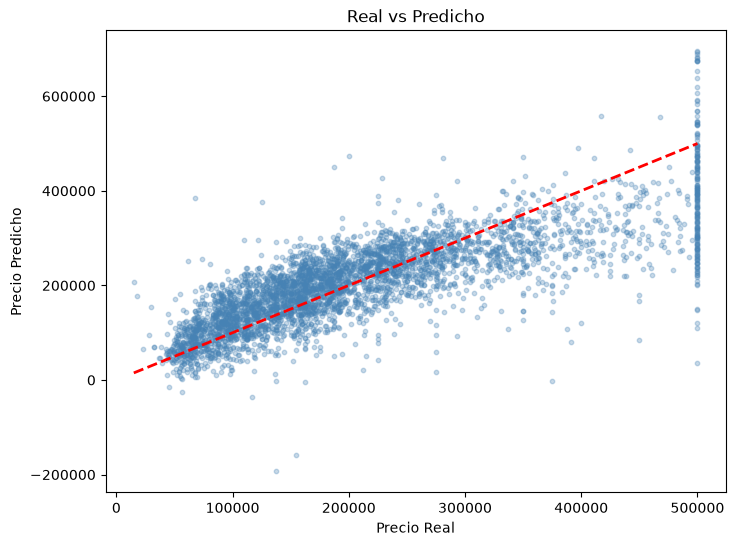

In [60]:
# Grafico los precios reales vs los predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Real vs Predicho')
plt.show()

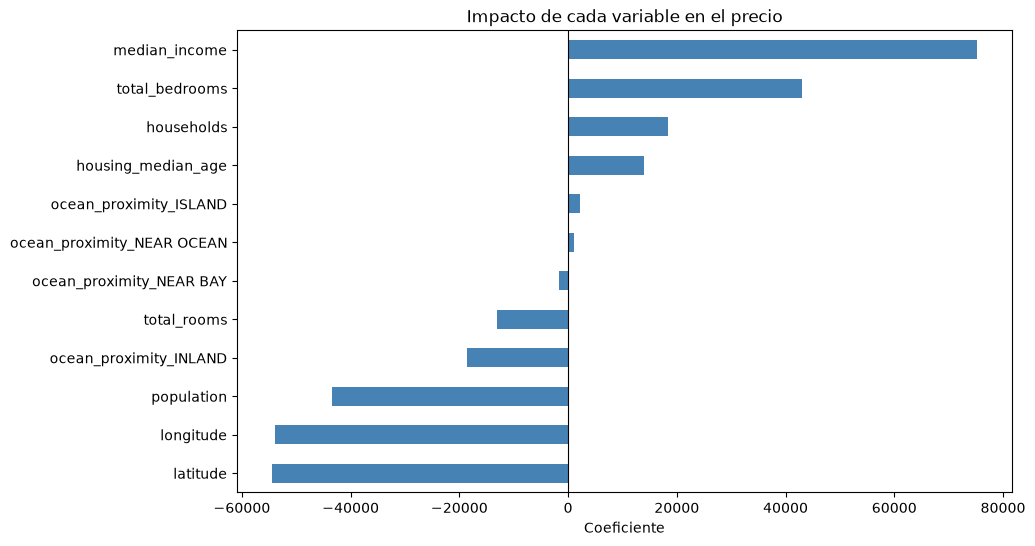

In [61]:
# Grafico los coeficientes del modelo
coeficientes = pd.Series(modelo.coef_, index=X.columns)
coeficientes = coeficientes.sort_values()

plt.figure(figsize=(10, 6))
coeficientes.plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Impacto de cada variable en el precio')
plt.xlabel('Coeficiente')
plt.show()

## Interpretación de Resultados

El modelo de regresión lineal predijo el precio de 4,128 casas que nunca había visto.

- **RMSE: $70,051** — en promedio el modelo se equivoca $70,051 por casa.
  Sobre un precio promedio de ~$207,000 eso es un error del 33%.
- **R²: 0.6255** — el modelo explica el 62% de por qué los precios varían entre casas.
  El 38% restante depende de factores que no tenemos — estado del inmueble,
  año de construcción, calidad del barrio.

El gráfico Real vs Predicho muestra que el modelo va en la dirección correcta
pero con bastante dispersión. La columna vertical en $500,000 es el censoring
que ya identificamos en el Challenge 1.

Con un error de $70,000 el modelo puede orientar una decisión pero no es 
suficiente para decir con certeza si una casa está sobrevaluada — salvo que 
la diferencia entre el precio pedido y el predicho sea muy grande (más de $150,000).

## Conclusiones

- La regresión lineal captura el patrón general de precios pero con un error considerable.
- Intentamos mejorar el modelo agregando features nuevas (ratios entre variables)
  pero el RMSE empeoró — con regresión lineal los datos básicos funcionaron mejor.
- El límite no es el código sino el modelo: una recta no puede representar
  algo tan complejo como el precio de una casa.
- Para mejorar la precisión se necesitaría un modelo no lineal como Random Forest
  o eliminar el censoring de $500,001 antes de entrenar.